I0000 00:00:1779784031.708874  205390 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779784031.723512  205851 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779784031.727355  205850 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  rPPG Capture Started
  Hold still for at least 15 seconds
  Press 'q' to stop


/opt/miniconda3/envs/rppg_env/lib/python3.11/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '



[Step 3 — POS Algorithm]
  Alpha (noise scale) : 0.3112
  Signal std          : 0.024259

[Step 1 — Detrend]
  Mean before : 0.0000
  Mean after  : 0.00000000

[Step 2 — Bandpass Filter]
  Range: 50 – 150 BPM

[Step 4 — Gaussian Smoothing] sigma=2

[Step 5 — FFT BPM]
  Peak frequency : 1.097 Hz
  Estimated BPM  : 65.84

[Step 3 — POS Algorithm]
  Alpha (noise scale) : 0.3354
  Signal std          : 0.054640

[Step 1 — Detrend]
  Mean before : 0.0000
  Mean after  : -0.00000000

[Step 2 — Bandpass Filter]
  Range: 50 – 150 BPM

[Step 4 — Gaussian Smoothing] sigma=2

[Step 5 — FFT BPM]
  Peak frequency : 1.100 Hz
  Estimated BPM  : 66.01

[Step 3 — POS Algorithm]
  Alpha (noise scale) : 0.3534
  Signal std          : 0.057863

[Step 1 — Detrend]
  Mean before : 0.0000
  Mean after  : -0.00000000

[Step 2 — Bandpass Filter]
  Range: 50 – 150 BPM

[Step 4 — Gaussian Smoothing] sigma=2

[Step 5 — FFT BPM]
  Peak frequency : 1.103 Hz
  Estimated BPM  : 66.16

[Step 3 — POS Algorithm]
  Alph

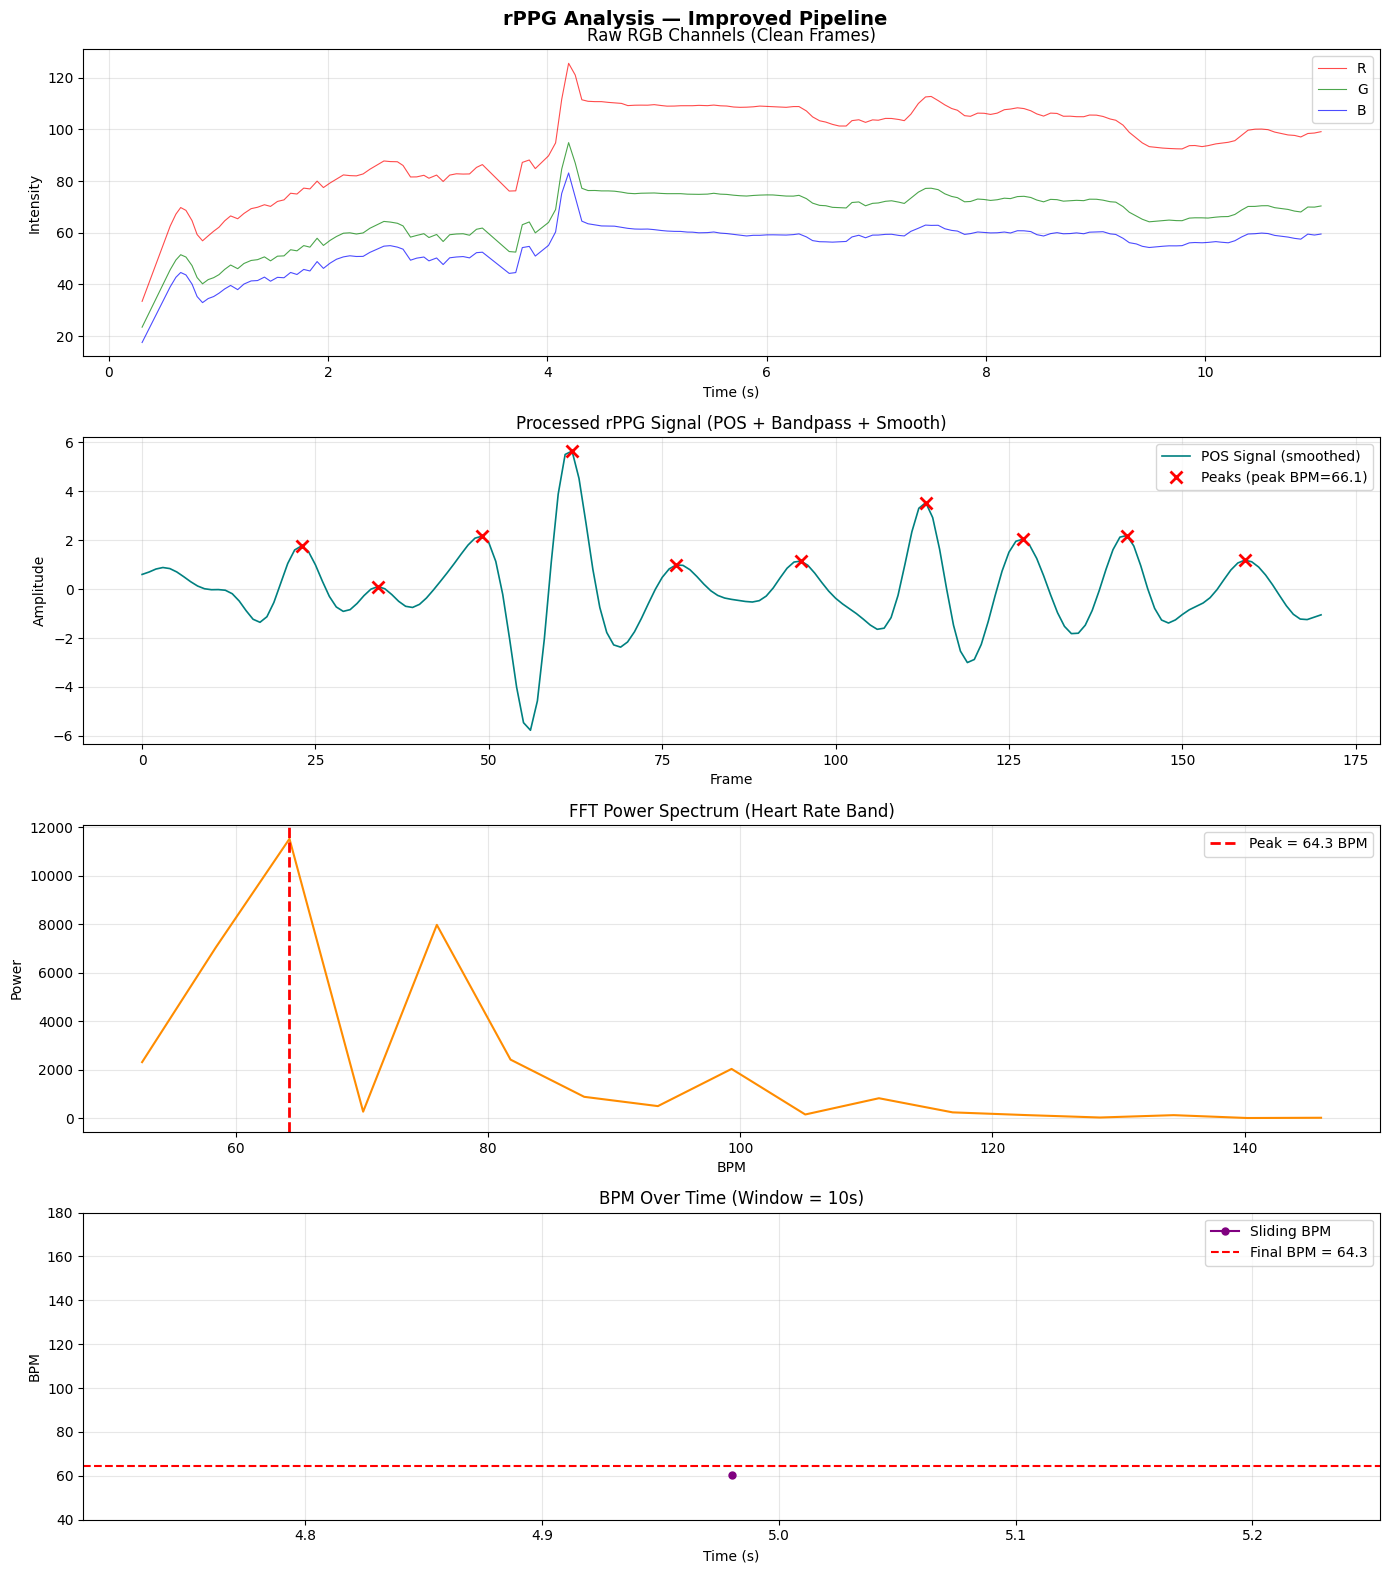


📊 Plot saved to rppg_results.png

  FINAL RESULT
  ✅ FFT BPM       : 64.3
  ✅ Peak BPM      : 66.1
  Difference      : 1.8 BPM — ✅ Good agreement

  🫀 ESTIMATED HEART RATE : 64.3 BPM
  ✅ Within normal range (50–150 BPM)


In [1]:
# ============================================================
# rPPG COMPLETE PIPELINE — IMPROVED
# POS Algorithm + FFT BPM + Motion Rejection
# ============================================================

# ============================================================
# IMPORTS
# ============================================================
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import gaussian_filter1d

# ============================================================
# CONFIG
# ============================================================
MIN_DURATION_SEC   = 15       # Minimum capture time for reliable BPM
BANDPASS_LOW_BPM   = 50       # 50 BPM lower bound
BANDPASS_HIGH_BPM  = 150      # 150 BPM upper bound
MOTION_THRESHOLD   = 15       # Max pixel shift allowed between frames
SAVE_CSV           = True     # Save RGB data to CSV after capture
CSV_PATH           = "rppg_data.csv"
WINDOW_SEC         = 10       # Sliding window size in seconds for live BPM
SMOOTH_SIGMA       = 2        # Gaussian smoothing sigma

# ============================================================
# MEDIAPIPE SETUP
# ============================================================
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ============================================================
# FOREHEAD ROI FUNCTION
# ============================================================
def get_forehead_roi(frame, face_landmarks, img_w, img_h):
    """
    Extract forehead ROI using MediaPipe face landmarks.
    Returns mean RGB values and bounding box.
    """
    lm = face_landmarks.landmark

    x1 = int(lm[103].x * img_w)
    x2 = int(lm[332].x * img_w)
    y1 = int(lm[10].y  * img_h)
    y2 = int((lm[70].y + lm[300].y) / 2 * img_h)

    # Validity check
    if x2 <= x1 or y2 <= y1:
        return None, None

    roi = frame[y1:y2, x1:x2]

    if roi.size == 0:
        return None, None

    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

    r = float(np.mean(roi_rgb[:, :, 0]))
    g = float(np.mean(roi_rgb[:, :, 1]))
    b = float(np.mean(roi_rgb[:, :, 2]))

    return (r, g, b), (x1, y1, x2, y2)

# ============================================================
# MOTION CHECK
# ============================================================
def is_motion_artifact(bbox, prev_bbox, threshold=MOTION_THRESHOLD):
    """
    Returns True if forehead ROI has shifted too much (motion artifact).
    """
    if prev_bbox is None:
        return False

    x1, y1, _, _ = bbox
    px1, py1, _, _ = prev_bbox

    shift = abs(x1 - px1) + abs(y1 - py1)
    return shift > threshold

# ============================================================
# STEP 1 — DETREND
# Remove slow illumination drift using mean subtraction
# ============================================================
def step1_detrend(signal):
    detrended = signal - np.mean(signal)
    print(f"\n[Step 1 — Detrend]")
    print(f"  Mean before : {np.mean(signal):.4f}")
    print(f"  Mean after  : {np.mean(detrended):.8f}")
    return detrended

# ============================================================
# STEP 2 — BANDPASS FILTER
# Keep only heart rate frequency range
# ============================================================
def step2_bandpass(signal, fps):
    low  = (BANDPASS_LOW_BPM  / 60) / (fps / 2)
    high = (BANDPASS_HIGH_BPM / 60) / (fps / 2)

    # Clamp to valid Nyquist range
    low  = np.clip(low,  0.001, 0.999)
    high = np.clip(high, 0.001, 0.999)

    if low >= high:
        print("[Step 2 — Bandpass] WARNING: Invalid frequency range, skipping filter.")
        return signal

    b, a = butter(N=3, Wn=[low, high], btype='band')
    filtered = filtfilt(b, a, signal)

    print(f"\n[Step 2 — Bandpass Filter]")
    print(f"  Range: {BANDPASS_LOW_BPM} – {BANDPASS_HIGH_BPM} BPM")
    return filtered

# ============================================================
# STEP 3 — POS ALGORITHM
# Plane-Orthogonal-to-Skin: uses all 3 channels to cancel motion
# de Haan & Jeanne (2013)
# ============================================================
def step3_pos(r_arr, g_arr, b_arr):
    """
    POS rPPG signal extraction.
    Normalizes each channel then projects onto the skin-orthogonal plane.
    """
    r_n = r_arr / (np.mean(r_arr) + 1e-8)
    g_n = g_arr / (np.mean(g_arr) + 1e-8)
    b_n = b_arr / (np.mean(b_arr) + 1e-8)

    # POS projection vectors
    s1 =  g_n - b_n              # tangent to skin
    s2 = -2*r_n + g_n + b_n      # orthogonal

    # Scale factor to minimize noise
    alpha = np.std(s1) / (np.std(s2) + 1e-8)

    pos_signal = s1 - alpha * s2

    print(f"\n[Step 3 — POS Algorithm]")
    print(f"  Alpha (noise scale) : {alpha:.4f}")
    print(f"  Signal std          : {np.std(pos_signal):.6f}")

    return pos_signal

# ============================================================
# STEP 4 — SMOOTH
# ============================================================
def step4_smooth(signal):
    smoothed = gaussian_filter1d(signal, sigma=SMOOTH_SIGMA)
    print(f"\n[Step 4 — Gaussian Smoothing] sigma={SMOOTH_SIGMA}")
    return smoothed

# ============================================================
# STEP 5 — FFT BPM (primary method)
# More robust than peak counting, especially for short signals
# ============================================================
def step5_fft_bpm(signal, fps):
    """
    Estimate BPM using FFT peak in the heart rate frequency band.
    """
    n      = len(signal)
    fft    = np.fft.rfft(signal)
    freqs  = np.fft.rfftfreq(n, d=1.0/fps)
    power  = np.abs(fft) ** 2

    # Mask to valid heart rate range
    low_hz  = BANDPASS_LOW_BPM  / 60.0
    high_hz = BANDPASS_HIGH_BPM / 60.0
    mask    = (freqs >= low_hz) & (freqs <= high_hz)

    if not np.any(mask):
        print("[Step 5 — FFT BPM] No frequencies in range.")
        return None, freqs, power

    peak_freq = freqs[mask][np.argmax(power[mask])]
    bpm       = peak_freq * 60.0

    print(f"\n[Step 5 — FFT BPM]")
    print(f"  Peak frequency : {peak_freq:.3f} Hz")
    print(f"  Estimated BPM  : {bpm:.2f}")

    return bpm, freqs, power

# ============================================================
# STEP 5B — PEAK-BASED BPM (backup method)
# ============================================================
def step5b_peak_bpm(signal, fps):
    """
    Backup BPM from peak counting.
    """
    min_distance = int(fps * 0.5)
    peaks, _     = find_peaks(
        signal,
        distance=min_distance,
        prominence=np.std(signal) * 0.3
    )

    print(f"\n[Step 5B — Peak BPM]")
    print(f"  Peaks found : {len(peaks)}")

    if len(peaks) < 2:
        return None, peaks

    rr_intervals = np.diff(peaks) / fps
    bpm = 60.0 / np.mean(rr_intervals)

    print(f"  Peak-based BPM : {bpm:.2f}")
    return bpm, peaks

# ============================================================
# SLIDING WINDOW BPM
# Compute BPM every N frames using a rolling window
# ============================================================
def sliding_window_bpm(signal, fps, window_sec=WINDOW_SEC):
    """
    Returns list of (time_sec, bpm) tuples for a timeline of BPM estimates.
    """
    window = int(window_sec * fps)
    step   = int(fps)          # Slide by 1 second
    results = []

    for start in range(0, len(signal) - window, step):
        chunk = signal[start : start + window]
        bpm, _, _ = step5_fft_bpm(chunk, fps)
        t_sec = (start + window / 2) / fps
        if bpm:
            results.append((round(t_sec, 2), round(bpm, 1)))

    return results

# ============================================================
# COMPUTE ACCURATE FPS FROM TIMESTAMPS
# ============================================================
def compute_fps(timestamps):
    if len(timestamps) < 2:
        return 30.0  # fallback
    diffs = np.diff(timestamps)
    fps   = 1.0 / np.mean(diffs)
    return fps

# ============================================================
# MAIN CAMERA CAPTURE
# ============================================================
cap = cv2.VideoCapture(0)

timestamps  = []
r_signal    = []
g_signal    = []
b_signal    = []
motion_flags = []

prev_bbox   = None
frame_idx   = 0
start_time  = time.time()
live_bpm    = None

print("=" * 50)
print("  rPPG Capture Started")
print(f"  Hold still for at least {MIN_DURATION_SEC} seconds")
print("  Press 'q' to stop")
print("=" * 50)

# ============================================================
# CAPTURE LOOP
# ============================================================
while True:

    ret, frame = cap.read()
    if not ret:
        break

    h, w   = frame.shape[:2]
    rgb_fr = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    t      = time.time() - start_time

    results = face_mesh.process(rgb_fr)

    if results.multi_face_landmarks:

        rgb, bbox = get_forehead_roi(
            frame,
            results.multi_face_landmarks[0],
            w, h
        )

        if rgb and bbox:
            r, g, b = rgb

            # --- QUALITY GATES ---
            # 1. Reject dark/noisy frames
            if g < 20:
                prev_bbox = bbox
                continue

            # 2. Motion artifact check
            motion = is_motion_artifact(bbox, prev_bbox)
            motion_flags.append(motion)

            # Always record, but flag motion frames
            timestamps.append(t)
            r_signal.append(r)
            g_signal.append(g)
            b_signal.append(b)

            prev_bbox = bbox

            # --- LIVE BPM (every 30 frames after enough data) ---
            if len(g_signal) >= 60 and frame_idx % 30 == 0:
                try:
                    _fps = compute_fps(timestamps)
                    _r   = np.array(r_signal[-int(_fps*10):])
                    _g   = np.array(g_signal[-int(_fps*10):])
                    _b   = np.array(b_signal[-int(_fps*10):])
                    if len(_g) > 20:
                        _pos     = step3_pos(_r, _g, _b)
                        _det     = step1_detrend(_pos)
                        _filt    = step2_bandpass(_det, _fps)
                        _sm      = step4_smooth(_filt)
                        live_bpm, _, _ = step5_fft_bpm(_sm, _fps)
                except Exception:
                    pass

            # --- DRAW ---
            x1, y1, x2, y2 = bbox
            color = (0, 0, 255) if motion else (0, 255, 0)

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            label = "MOTION" if motion else f"G:{g:.0f}"
            cv2.putText(frame, label, (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

            # Live BPM display
            if live_bpm:
                cv2.putText(frame, f"BPM: {live_bpm:.0f}",
                            (10, 35), cv2.FONT_HERSHEY_SIMPLEX,
                            1.1, (0, 200, 255), 3)

            # Timer
            elapsed = int(t)
            status  = "RECORDING" if elapsed < MIN_DURATION_SEC else "READY (press q)"
            cv2.putText(frame, f"{elapsed}s | {status}",
                        (10, h - 15), cv2.FONT_HERSHEY_SIMPLEX,
                        0.55, (200, 200, 200), 1)

    cv2.imshow("rPPG — Press Q to stop", frame)
    frame_idx += 1

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ============================================================
# CLEANUP
# ============================================================
cap.release()
cv2.destroyAllWindows()
face_mesh.close()

print("\n✅ Capture Complete")

# ============================================================
# VALIDATE CAPTURE
# ============================================================
if len(timestamps) < 2:
    print("❌ Not enough frames captured. Exiting.")
    exit()

fps      = compute_fps(timestamps)
duration = timestamps[-1] - timestamps[0]
n_motion = sum(motion_flags)
n_clean  = len(motion_flags) - n_motion

print(f"  Total Frames    : {len(g_signal)}")
print(f"  Duration        : {duration:.2f} sec")
print(f"  FPS (actual)    : {fps:.2f}")
print(f"  Motion Frames   : {n_motion} ({100*n_motion/max(len(motion_flags),1):.1f}%)")
print(f"  Clean Frames    : {n_clean}")

if duration < MIN_DURATION_SEC:
    print(f"\n⚠️  Warning: Only {duration:.1f}s captured. "
          f"Recommended: {MIN_DURATION_SEC}s for accurate BPM.")

# ============================================================
# SAVE CSV
# ============================================================
if SAVE_CSV:
    df = pd.DataFrame({
        "time_s"   : timestamps,
        "R"        : r_signal,
        "G"        : g_signal,
        "B"        : b_signal,
        "motion"   : motion_flags
    })
    df.to_csv(CSV_PATH, index=False)
    print(f"\n💾 Data saved to: {os.path.abspath(CSV_PATH)}")
    print(df.head(10).to_string(index=False))

# ============================================================
# FILTER OUT MOTION FRAMES FOR ANALYSIS
# ============================================================
r_arr = np.array(r_signal)
g_arr = np.array(g_signal)
b_arr = np.array(b_signal)
t_arr = np.array(timestamps)
m_arr = np.array(motion_flags, dtype=bool)

# Use clean frames only
clean = ~m_arr
if clean.sum() < 30:
    print("\n⚠️  Too many motion frames — using all frames for analysis.")
    clean = np.ones(len(m_arr), dtype=bool)

r_c = r_arr[clean]
g_c = g_arr[clean]
b_c = b_arr[clean]

# ============================================================
# PIPELINE
# ============================================================
print("\n" + "="*50)
print("  PREPROCESSING PIPELINE")
print("="*50)

# Step 1 — Detrend each channel
r_det = step1_detrend(r_c)
g_det = step1_detrend(g_c)
b_det = step1_detrend(b_c)

# Step 2 — Bandpass each channel
r_bp  = step2_bandpass(r_det, fps)
g_bp  = step2_bandpass(g_det, fps)
b_bp  = step2_bandpass(b_det, fps)

# Step 3 — POS algorithm
pos_signal = step3_pos(r_bp, g_bp, b_bp)

# Step 4 — Smooth
smoothed = step4_smooth(pos_signal)

# Step 5 — FFT BPM (primary)
bpm_fft, freqs, power = step5_fft_bpm(smoothed, fps)

# Step 5B — Peak BPM (backup / cross-check)
bpm_peak, peaks = step5b_peak_bpm(smoothed, fps)

# Sliding window BPM timeline
print("\n[Sliding Window BPM]")
bpm_timeline = sliding_window_bpm(smoothed, fps)
for t_sec, bpm_val in bpm_timeline:
    print(f"  t={t_sec:.1f}s → {bpm_val:.1f} BPM")

# ============================================================
# CHOOSE FINAL BPM
# FFT is primary; fall back to peak if FFT fails
# ============================================================
final_bpm = bpm_fft if bpm_fft else bpm_peak

# ============================================================
# PLOTS
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle("rPPG Analysis — Improved Pipeline", fontsize=14, fontweight='bold')

# — Plot 1: Raw RGB channels —
axes[0].plot(t_arr[clean], r_c, color='red',   alpha=0.7, label='R', linewidth=0.8)
axes[0].plot(t_arr[clean], g_c, color='green', alpha=0.7, label='G', linewidth=0.8)
axes[0].plot(t_arr[clean], b_c, color='blue',  alpha=0.7, label='B', linewidth=0.8)
axes[0].set_title("Raw RGB Channels (Clean Frames)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Intensity")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# — Plot 2: POS Signal (after bandpass) —
frame_axis = np.arange(len(smoothed))
axes[1].plot(frame_axis, smoothed, color='teal', linewidth=1.2, label='POS Signal (smoothed)')
if len(peaks) > 0:
    axes[1].plot(peaks, smoothed[peaks], 'rx', markersize=9,
                 markeredgewidth=2, label=f'Peaks (peak BPM={bpm_peak:.1f})')
axes[1].set_title("Processed rPPG Signal (POS + Bandpass + Smooth)")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Amplitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# — Plot 3: FFT Power Spectrum —
low_hz  = BANDPASS_LOW_BPM  / 60.0
high_hz = BANDPASS_HIGH_BPM / 60.0
mask    = (freqs >= low_hz) & (freqs <= high_hz)

axes[2].plot(freqs[mask] * 60, power[mask], color='darkorange', linewidth=1.5)
if bpm_fft:
    axes[2].axvline(bpm_fft, color='red', linestyle='--', linewidth=2,
                    label=f'Peak = {bpm_fft:.1f} BPM')
axes[2].set_title("FFT Power Spectrum (Heart Rate Band)")
axes[2].set_xlabel("BPM")
axes[2].set_ylabel("Power")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# — Plot 4: Sliding Window BPM —
if bpm_timeline:
    times_sw = [x[0] for x in bpm_timeline]
    bpms_sw  = [x[1] for x in bpm_timeline]
    axes[3].plot(times_sw, bpms_sw, 'o-', color='purple',
                 linewidth=1.5, markersize=5, label='Sliding BPM')
    axes[3].axhline(final_bpm, color='red', linestyle='--',
                    linewidth=1.5, label=f'Final BPM = {final_bpm:.1f}')
    axes[3].set_title(f"BPM Over Time (Window = {WINDOW_SEC}s)")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylabel("BPM")
    axes[3].set_ylim([40, 180])
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
else:
    axes[3].text(0.5, 0.5, "Not enough data for sliding window",
                 ha='center', va='center', transform=axes[3].transAxes)

plt.tight_layout()
plt.savefig("rppg_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Plot saved to rppg_results.png")

# ============================================================
# FINAL RESULT
# ============================================================
print("\n" + "="*50)
print("  FINAL RESULT")
print("="*50)

if final_bpm:
    print(f"  ✅ FFT BPM       : {bpm_fft:.1f}" if bpm_fft else "  ❌ FFT BPM       : failed")
    print(f"  ✅ Peak BPM      : {bpm_peak:.1f}" if bpm_peak else "  ❌ Peak BPM      : failed")

    # Agreement check
    if bpm_fft and bpm_peak:
        diff = abs(bpm_fft - bpm_peak)
        agree = "✅ Good agreement" if diff < 10 else "⚠️  Methods disagree"
        print(f"  Difference      : {diff:.1f} BPM — {agree}")

    print(f"\n  🫀 ESTIMATED HEART RATE : {final_bpm:.1f} BPM")

    if   final_bpm < 50:
        print("  ⚠️  Bradycardia range — verify signal quality")
    elif final_bpm > 150:
        print("  ⚠️  Tachycardia range — verify signal quality")
    else:
        print("  ✅ Within normal range (50–150 BPM)")
else:
    print("  ❌ BPM could not be estimated")
    print("  Tips: Ensure good lighting, hold still, capture >15 seconds")

print("="*50)